## Notebook 2 - Hierarchical Clustering & Alternative Clustering Algorithms

### 1. Exploratory Data Analysis +  Features Insight

#### Imports

In [37]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import (AgglomerativeClustering, DBSCAN, estimate_bandwidth, MeanShift)

from scipy.cluster.hierarchy import (dendrogram, linkage)
from scipy.spatial.distance import (squareform, pdist)

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

np.random.seed(24)
# stores the randomely generated data in seed 24

In [3]:
# Importing dataframe from Notebook 1

df = pd.read_csv('segmented_marketing_campaigns.csv').drop(columns = ['gmm_clusters', 'campaign_persona'])

df.head()

,ad_budget,impressions,ctr,clicks,cpc,time_on_site,user_engagement_score,device_score,clusters
0,38931.699766,582346,0.040196,24852,1.514721,109.930284,30.446278,7,3
1,33771.638731,373635,0.028582,11998,3.369712,175.661388,32.410409,6,1
2,4704.227014,20361,0.017892,341,15.532846,454.217952,28.186966,1,2
3,39417.315326,635976,0.044160,29147,1.301943,60.987286,26.207460,7,3
4,39487.870658,601033,0.041437,26301,1.574464,86.270030,24.286618,7,3


In [4]:
df.nunique()

ad_budget                5000
impressions              4973
ctr                      5000
clicks                   4293
cpc                      5000
time_on_site             5000
user_engagement_score    5000
device_score               10
clusters                    4
dtype: int64

In [5]:
print('Dataframe Structure:\n')
df.info()

Dataframe Structure:

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ad_budget              5000 non-null   float64
 1   impressions            5000 non-null   int64  
 2   ctr                    5000 non-null   float64
 3   clicks                 5000 non-null   int64  
 4   cpc                    5000 non-null   float64
 5   time_on_site           5000 non-null   float64
 6   user_engagement_score  5000 non-null   float64
 7   device_score           5000 non-null   int64  
 8   clusters               5000 non-null   int64  
dtypes: float64(5), int64(4)
memory usage: 351.7 KB


In [6]:
print('Summary Statistics:\n')
df.describe()

Summary Statistics:



,ad_budget,impressions,ctr,clicks,cpc,time_on_site,user_engagement_score,device_score,clusters
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,28924.022935,320357.685600,0.032524,12036.598200,5.620529,280.893508,43.093493,4.439800,1.500000
std,12147.415367,205998.194005,0.009676,9092.191446,7.656043,150.262258,21.559853,2.098489,1.118146
min,1000.000000,2615.000000,0.010000,45.000000,1.090364,10.000000,0.000000,1.000000,0.000000
25%,20218.327129,114369.250000,0.023539,2665.000000,1.807244,140.292720,27.380184,3.000000,0.750000
50%,33349.103462,320737.500000,0.033615,11213.500000,3.033254,275.187379,35.934945,4.000000,1.500000
75%,38686.607153,495741.000000,0.041524,19631.500000,7.256431,422.041378,57.770751,6.000000,2.250000
max,50000.000000,834640.000000,0.050000,35633.000000,335.240041,600.000000,100.000000,10.000000,3.000000


In [7]:
print('Cluster Ratio:\n')
df['clusters'].value_counts(normalize = True)

Cluster Ratio:



clusters
3    0.25
1    0.25
2    0.25
0    0.25
Name: proportion, dtype: float64

In [8]:
print('Clusters Summary:\n')
df.groupby(by = 'clusters').mean()

Clusters Summary:



,ad_budget,impressions,ctr,clicks,cpc,time_on_site,user_engagement_score,device_score
clusters,,,,,,,,
0,38531.260077,423437.5608,0.042397,15981.4760,2.076471,381.700588,76.934256,2.7912
1,28567.385972,235139.4888,0.027300,7160.2552,4.818480,158.490047,39.777533,5.8400
2,9694.336505,46680.4584,0.019858,871.9560,13.936250,463.382301,29.995247,2.2216
3,38903.109186,576173.2344,0.040540,24132.7056,1.650915,120.001095,25.666935,6.9064


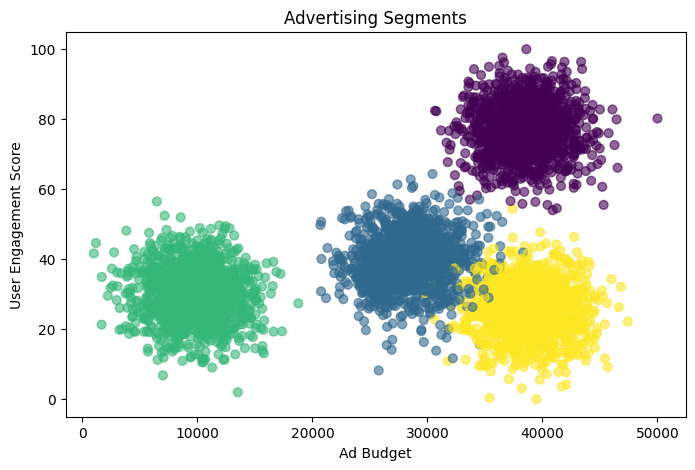

In [9]:
# Plotting Clusters of two features from df

plt.figure(figsize = (8,5))

plt.scatter(df['ad_budget'], df['user_engagement_score'], c = df['clusters'], s = 40, alpha = 0.6)

plt.title('Advertising Segments')
plt.xlabel('Ad Budget')
plt.ylabel('User Engagement Score')
plt.show();

### 2. Distance Matrix

A __Distance Matrix__ is a flat mathematical grid that tracks the straight-line (Euclidean) distance between every single row in dataset and every other row.

Because K-Means and Hierarchical Clustering cannot physically "see" data points, they rely entirely on geometry. The matrix translates rows of marketing metrics into a map of numbers.

#### Scaling Data

In [10]:
# Taking a random sample of 1000 rows to keep hierarchical computing efficient

df_sample = df.sample(n = 1000, random_state = 24).reset_index(drop = True)

print('The shape of Sample dataframe:', df_sample.shape)

The shape of Sample dataframe: (1000, 9)


__The Step-by-Step Memory Process__

1.  **Plotting Row 0 (The first 8D point):** The algorithm takes the 8 scaled numbers from first ad campaign row and uses them as 8 separate spatial coordinates. It plots this campaign as a single, absolute point sitting somewhere inside an 8-dimensional hyper-space.
2.  **Plotting Row 1 (The second 8D point):** It jumps to the second row of data, reads its 8 scaled numbers, and plots it as a second independent point inside that exact same 8D space.
3.  **Measuring the 8D Straight Line:** Now, it draws a straight line between those two points. To calculate the exact length of that line, `pdist` applies the multi-dimensional Euclidean formula:
    *   It subtracts the `ad_budget` of Row 0 from Row 1 and squares the result.
    *   It subtracts the `impressions` of Row 0 from Row 1 and squares the result.
    *   It repeats this subtraction and squaring for all 8 feature columns.
    *   Finally, it adds all 8 of those squared numbers together and takes the square root of the grand total.
4.  **The Loop Continues:** Once it records that first straight-line length, it keeps Row 0 locked in place, moves to Row 2, plots it as another 8D point, and measures that new distance. It repeats this relentlessly until every single pair combination of your 1,000 rows has been mapped, measured, and stored in memory.

In [11]:
# Applying Standard Scaler for fair distance weighting

df_scaled = StandardScaler().fit_transform(df_sample.drop('clusters', axis = 1))

distance_matrix = squareform(
    # squareform reshapes the 1D array from pdist into 2D array
    pdist(
        df_scaled,
        metric = 'euclidean'
    ),
    # pdist stands for Pairwise Distance.
    # It takes sample 1,000 data rows and calculates the straight-line (Euclidean) distance from every single row to every other single row.
    # pdist outputs this as 1D array
)

print('Distance Matrix Shape:', distance_matrix.shape, '\n')
print('First Five Quadrant:\n', distance_matrix[:5, :5])

Distance Matrix Shape: (1000, 1000) 

First Five Quadrant:
 [[0.         5.44810928 5.65584068 1.36819919 6.53054011]
 [5.44810928 0.         0.83636968 6.21956559 1.32865065]
 [5.65584068 0.83636968 0.         6.39167888 1.09830924]
 [1.36819919 6.21956559 6.39167888 0.         7.2389313 ]
 [6.53054011 1.32865065 1.09830924 7.2389313  0.        ]]


#### Distance Matrix Heatmap

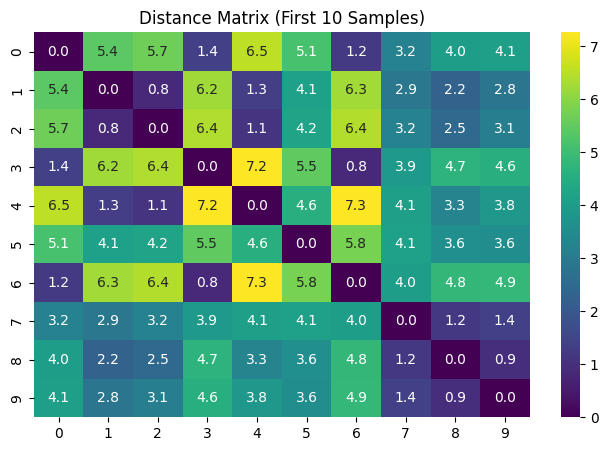

In [12]:
plt.figure(figsize = (8,5))

sns.heatmap(distance_matrix[:10, :10], cmap = 'viridis', annot = True, fmt = '.1f')

plt.title('Distance Matrix (First 10 Samples)')
plt.show();

### 3. Heararchical Linkages

While a distance matrix measures the distance between individual data points, a __Linkage__ is the mathematical rule that tells the algorithm _how to measure the distance_ between whole groups or clusters of points as they begin to merge.

As hierarchical clustering builds its tree, it starts by grouping the two closest single points together into a small cluster. But when it needs to compare that new cluster against a third point, or against another cluster, it needs a rule to judge proximity. That rule is linkage method:

__Single Linkage (Nearest Neighbor)__: Measures the distance between the two closest points in two different clusters. It tends to create long, stringy, chain-like clusters that are rarely useful for business segmentation.

__Complete Linkage (Furthest Neighbor)__: Measures the distance between the two furthest points in two different clusters. This forces clusters to be compact and tightly bounded.

__Average Linkage (UPGMA)__: Calculates the average distance between all pairs of points across both clusters, providing a balanced, stable middle ground.

__Ward’s Linkage (Minimum Variance)__: Instead of looking at individual point distances, Ward’s looks at the overall variance (Inertia) within the groups. It merges two clusters only if doing so results in the smallest possible increase in the total sum of squared errors.

In [13]:
linkage_methods = ['single', 'complete', 'average', 'ward']

linkages = {}

for method in linkage_methods:
    linkages[method] = linkage(
        df_scaled,
        method = method,
        metric = 'euclidean'
    )

#### Plotting Dendrogram

A Dendrogram is a visual tree diagram that illustrates the step-by-step history of how data points were merged together by the hierarchical clustering algorithm.

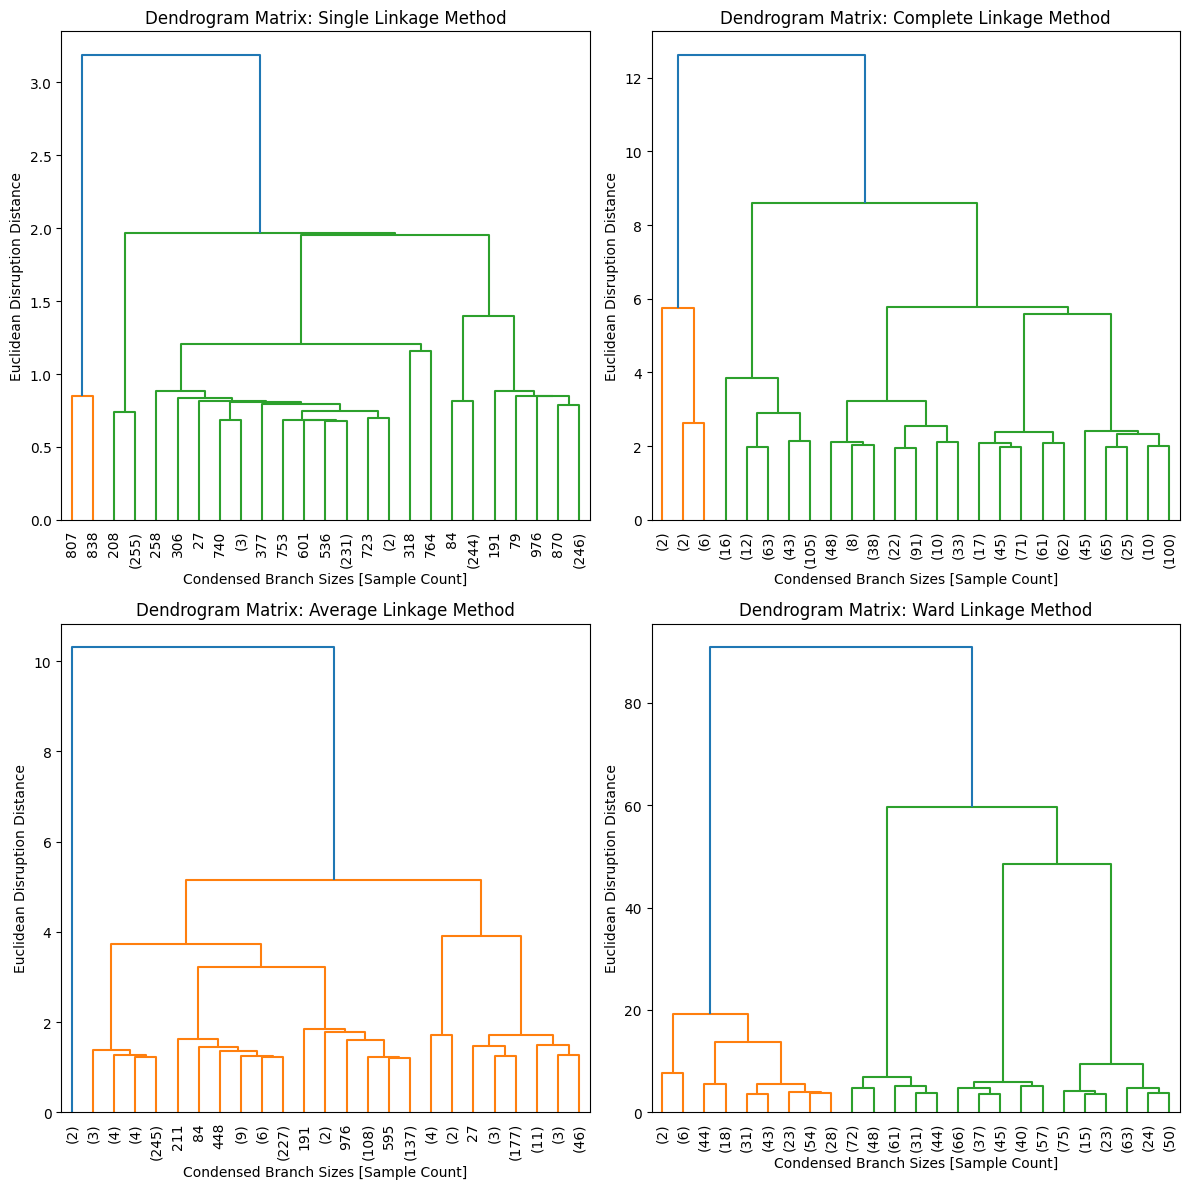

In [14]:
fig, axes = plt.subplots(2, 2, figsize = (12,12))

axes_flat = axes.ravel()

for idx, method in enumerate(linkages.keys()):
    # targetting the current blank box in the grid
    ax = axes_flat[idx]

    # plotting the dendrogram directly into the targetted box
    dendrogram(
        linkages[method],
        truncate_mode = 'lastp',
        # 'lastp' truncates the tree showing only the last few top-level branches of the tree
        p = 25,
        # shows exactly the last 25 clusters that were merged
        leaf_rotation = 90,
        # rotates the text label along horizontal axis
        ax = ax
    )

    ax.set_title(f'Dendrogram Matrix: {method.capitalize()} Linkage Method')
    ax.set_xlabel('Condensed Branch Sizes [Sample Count]')
    ax.set_ylabel('Euclidean Disruption Distance')
    
plt.tight_layout()
plt.show();

### 4. Agglomerative Clustering (Ward linkage)

Agglomerative Clustering is the formal, algorithmic execution of bottom-up hierarchical clustering.

In [15]:
agg_model = AgglomerativeClustering(
    n_clusters = 4,
    linkage = 'ward'
)

agg_pred = agg_model.fit_predict(df_sample)

df_sample['agg_clusters'] = agg_pred

print('Hierarchical Cluster Distribution:\n', df_sample['agg_clusters'].value_counts().sort_index())

Hierarchical Cluster Distribution:
 agg_clusters
0    305
1    255
2    248
3    192
Name: count, dtype: int64


**Key takeaway**

Ideally each cluster should have even allocation thought since the Agglomerative Clustering is applied onto the df_sample, the uneven numbers could be caused due to sampling error, i.e. Out of the 1000 rows, every 250 rows not belonging to 1 cluster each.

In [16]:
df_sample.head()

,ad_budget,impressions,ctr,clicks,cpc,time_on_site,user_engagement_score,device_score,clusters,agg_clusters
0,11906.880747,62427,0.021087,1263,10.701997,438.254852,18.194972,2,2,2
1,36306.065526,478661,0.041990,20999,1.742935,123.141463,21.936816,7,3,0
2,36039.772545,608496,0.038142,23702,1.476780,149.700788,23.916203,7,3,0
3,9182.470640,29637,0.017813,505,17.702593,475.003554,33.068893,2,2,2
4,39417.315326,635976,0.044160,29147,1.301943,60.987286,26.207460,7,3,0


In [17]:
print('Aggregated Clustering Profile:\n')
df_sample.groupby(by = ['agg_clusters']).mean()

Aggregated Clustering Profile:



,ad_budget,impressions,ctr,clicks,cpc,time_on_site,user_engagement_score,device_score,clusters
agg_clusters,,,,,,,,,
0,38983.503021,556633.436066,0.040918,22808.852459,1.685668,180.680579,37.284891,5.967213,2.311475
1,36149.652701,375164.266667,0.039158,13823.196078,2.516064,318.706983,66.153725,3.705882,0.392157
2,9668.659034,45180.241935,0.019714,837.495968,14.555541,466.130957,29.426151,2.181452,2.000000
3,27794.434493,218690.135417,0.027314,6672.343750,5.007052,158.615014,39.774347,5.791667,1.000000


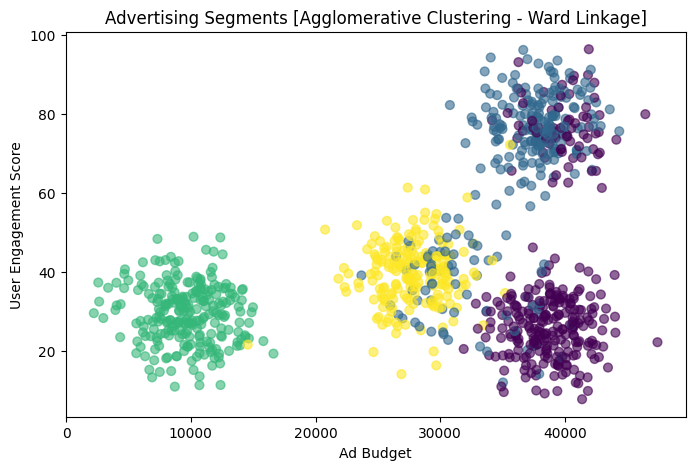

In [18]:
plt.figure(figsize = (8,5))

plt.scatter(df_sample['ad_budget'], df_sample['user_engagement_score'], c = df_sample['agg_clusters'], s = 40, alpha = 0.6)

plt.title('Advertising Segments [Agglomerative Clustering - Ward Linkage]')
plt.xlabel('Ad Budget')
plt.ylabel('User Engagement Score')

plt.show();

In [19]:
pd.crosstab(df_sample['clusters'], df_sample['agg_clusters'])

agg_clusters,0,1,2,3
clusters,,,,
0,70,185,0,1
1,0,55,0,190
2,0,0,248,1
3,235,15,0,0


__Key takeaways__

- Original Cluster 2 maps to Hierarchical cluster 2 - 248 data points match with only 1 point straying
- Original Cluster 3 maps to Hierarchical cluster 0 - 235 data poitns match
- Original Cluster 0 maps to Hierarchical cluster 1 - 185 data poitns match
- Original Cluster 1 maps to Hierarchical cluster 3 - 190 data poitns match

- Migrations - 70 rows shifted between segments and 55 rows shifted between others.

This structural divergence perfectly highlights the algorithmic differences between the two methods. While K-Means constructs rigid, linear Voronoi tessellations based purely on global centroid proximity, Agglomerative clustering builds fluid boundaries from the bottom up based on local neighborhood connectivity and variance minimisation. These marginal reassignments represent the 'borderline' campaigns sitting in the overlapping zones of the marketing funnel.

#### Helper functions: run_clustering (engine)

In [26]:
def run_clustering(data, model_object, label_column_name = 'clusters'):
    # label_column_name set to 'clusters' as default if not defined when using helper function
    
    df_copy = data.copy()
    # creates a copy of data to avoid modifying original df

    marketing_features = [
        'ad_budget', 'impressions', 'ctr', 'clicks', 'cpc', 'time_on_site', 'user_engagement_score', 'device_score'
    ]
    features_only = df_copy[marketing_features]
    # prevents old cluster columns from being treated as marketing matrics when training models

    scaled_features = StandardScaler().fit_transform(features_only)
    # applying Standard Scaling to eliminate feature dominance

    # Agglomerative Clustering /K-Means usually have a combined .fit_predict() method.
    # Gaussian Mixture Models (GMM) requires the model to be trained .fit() first then assign labels .predict()
    # hasattr() (has attribute) builds a flexible pipeline that can handle both styles of models without crashing

    if hasattr(model_object, 'fit_predict'):
        labels = model_object.fit_predict(scaled_features)

    else:
        model_object.fit(scaled_features)
        labels = model_object.predict(scaled_features)

    df_copy[label_column_name] = labels
    return df_copy

#### Helper function: profile_clusters (analyst)

In [21]:
def profile_clusters(data, cluster_column):

    print('Cluster Profile Report for:', cluster_column)
    counts = data[cluster_column].value_counts().sort_index()

    print('\nData Points per Cluster:')
    for cluster_id, count in counts.items():
        print(f'Cluster {cluster_id}: {count} campaigns')
    
    print('\nArithmetic Mean Profiles:')
    df_numeric = data.select_dtypes(include = ['number'])
    # dropping the non-numeric text columns
    profiles = df_numeric.groupby(by = cluster_column).mean().round(3)

    return profiles

### 5. DBSCAN

Unlike K-Means and Hierarchical clustering—which are forced to assign every single data point to a group — _DBSCAN_ is a density-based algorithm. If a campaign sits in a highly isolated region of the 8D space with fewer than 10 neighbors within a radius of 1.2, DBSCAN explicitly labels it as `-1`. This means it has flagged the row as an outlier or background noise.

In [27]:
dbscan_model = DBSCAN(
    eps = 1.2,
    # Epsilon radius - the maximum straight-line (Euclidean) distance the sensor will look around any given point to find neighbors
    min_samples = 10
    # the minimum number of data points required inside an Epsilon radius to officially declare that area a 'dense cluster core' 
)
# Hence, an ad campaign must have at least 10 neighboring campaigns within 1.2 epsilon radius to be considered part of a real marketing segment.

df_sample = run_clustering(df_sample, dbscan_model, 'db_clusters')

df_sample.head()

,ad_budget,impressions,ctr,clicks,cpc,time_on_site,user_engagement_score,device_score,clusters,agg_clusters,db_clusters
0,11906.880747,62427,0.021087,1263,10.701997,438.254852,18.194972,2,2,2,0
1,36306.065526,478661,0.041990,20999,1.742935,123.141463,21.936816,7,3,0,1
2,36039.772545,608496,0.038142,23702,1.476780,149.700788,23.916203,7,3,0,1
3,9182.470640,29637,0.017813,505,17.702593,475.003554,33.068893,2,2,2,0
4,39417.315326,635976,0.044160,29147,1.301943,60.987286,26.207460,7,3,0,1


In [28]:
profile_clusters(df_sample, 'db_clusters')

Cluster Profile Report for: db_clusters

Data Points per Cluster:
Cluster -1: 4 campaigns
Cluster 0: 245 campaigns
Cluster 1: 250 campaigns
Cluster 2: 256 campaigns
Cluster 3: 245 campaigns

Arithmetic Mean Profiles:


,ad_budget,impressions,ctr,clicks,cpc,time_on_site,user_engagement_score,device_score,clusters,agg_clusters
db_clusters,,,,,,,,,,
-1,8397.799,10317.750,0.020,187.250,55.782,468.046,28.519,2.250,2.0,2.000
0,9709.388,46106.229,0.020,854.155,13.851,466.097,29.409,2.176,2.0,2.004
1,38596.381,565885.432,0.040,23679.860,1.669,121.758,25.560,6.916,3.0,0.060
2,38397.092,419896.602,0.043,15871.762,2.072,381.122,77.100,2.805,0.0,0.734
3,28372.843,238086.151,0.027,7254.086,4.745,156.571,39.708,5.833,1.0,2.551


#### Noise Points

In [29]:
df_sample[df_sample['db_clusters'] == -1]

# DBSCAN flagged below 4 campaigns from df_sample as 'outliers'

,ad_budget,impressions,ctr,clicks,cpc,time_on_site,user_engagement_score,device_score,clusters,agg_clusters,db_clusters
318,12022.673123,17742,0.019121,325,42.479696,518.079887,20.480638,2,2,2,-1
764,9891.498535,13981,0.018315,241,46.902380,493.094364,37.333379,3,2,2,-1
807,6055.832678,5128,0.019635,95,67.397543,421.243490,36.847103,2,2,2,-1
838,5621.192354,4420,0.021791,88,66.347284,439.766811,19.415653,2,2,2,-1


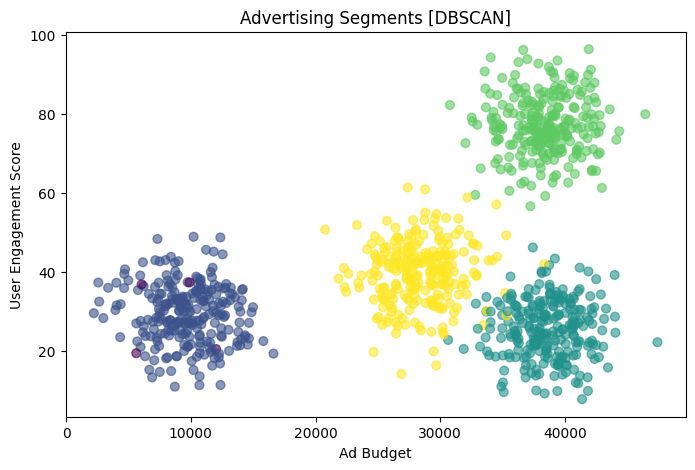

In [30]:
plt.figure(figsize = (8,5))

plt.scatter(df_sample['ad_budget'], df_sample['user_engagement_score'], c = df_sample['db_clusters'], s = 40, alpha = 0.6)

plt.title('Advertising Segments [DBSCAN]')
plt.xlabel('Ad Budget')
plt.ylabel('User Engagement Score')

plt.show();

__Key takeaway__

Unlike previous partition and hierarchical methods, DBSCAN groups our data based on localised multi-dimensional density rather than global geometry or tree connections.

The algorithm's performance is stellar, yielding the following insights:

* **Organic Cluster Discovery:** Without any prior instruction regarding the number of segments ($K$), DBSCAN independently discovered exactly **four distinct density cores**. The highly balanced distribution (ranging between 245 and 256 campaigns per cluster) strongly validates the stability of our underlying marketing personas.


* **Anomaly Identification (Cluster -1):** DBSCAN successfully isolated **4 campaigns as statistical noise**. Because these rows fell short of the minimum density threshold within our 8D spatial radius, they have been flagged as operational outliers. In a production pipeline, these campaigns would be isolated for a dedicated anomaly audit or extreme black-swan marketing events.

### 6. Mean Shift

**Mean Shift** uses a concept called __Kernel Density Estimation (KDE)__ to climb hills of data.

It is a centroid-based, density-climbing algorithm. Instead of looking at distances globally or connecting local points like a grid, Mean Shift treats data space like a rugged, mountainous landscape where the most crowded areas form the peaks.

In [31]:
# bandwidth dictates the physical radius of the sliding windows used to look for data points
est_bandwidth = estimate_bandwidth(
    df_scaled,
    quantile = 0.2,
    # measure the distances between all nearest neighbors, and find the 20th percentile (the lowest 20%) of those distances
    n_samples = 500
    )

print('Automatically Estimated Bandwidth:', est_bandwidth.round(3), '\n')

meanshift_model = MeanShift(
    bandwidth = est_bandwidth,
    bin_seeding = True
    # bin_seeding = True groups the data into a bins first and only starts windows from the center of those bins
    # this speeds algorithm without sacrificing accuracy
)

df_sample = run_clustering(df_sample, meanshift_model, 'ms_clusters')

df_sample.head()

Automatically Estimated Bandwidth: 1.354 



,ad_budget,impressions,ctr,clicks,cpc,time_on_site,user_engagement_score,device_score,clusters,agg_clusters,db_clusters,ms_clusters
0,11906.880747,62427,0.021087,1263,10.701997,438.254852,18.194972,2,2,2,0,3
1,36306.065526,478661,0.041990,20999,1.742935,123.141463,21.936816,7,3,0,1,1
2,36039.772545,608496,0.038142,23702,1.476780,149.700788,23.916203,7,3,0,1,1
3,9182.470640,29637,0.017813,505,17.702593,475.003554,33.068893,2,2,2,0,3
4,39417.315326,635976,0.044160,29147,1.301943,60.987286,26.207460,7,3,0,1,1


In [32]:
profile_clusters(df_sample, 'ms_clusters')

Cluster Profile Report for: ms_clusters

Data Points per Cluster:
Cluster 0: 256 campaigns
Cluster 1: 250 campaigns
Cluster 2: 245 campaigns
Cluster 3: 245 campaigns
Cluster 4: 4 campaigns

Arithmetic Mean Profiles:


,ad_budget,impressions,ctr,clicks,cpc,time_on_site,user_engagement_score,device_score,clusters,agg_clusters,db_clusters
ms_clusters,,,,,,,,,,,
0,38397.092,419896.602,0.043,15871.762,2.072,381.122,77.100,2.805,0.0,0.734,2.0
1,38596.381,565885.432,0.040,23679.860,1.669,121.758,25.560,6.916,3.0,0.060,1.0
2,28372.843,238086.151,0.027,7254.086,4.745,156.571,39.708,5.833,1.0,2.551,3.0
3,9709.388,46106.229,0.020,854.155,13.851,466.097,29.409,2.176,2.0,2.004,0.0
4,8397.799,10317.750,0.020,187.250,55.782,468.046,28.519,2.250,2.0,2.000,-1.0


In [36]:
df_sample[df_sample['ms_clusters'] == 4]

,ad_budget,impressions,ctr,clicks,cpc,time_on_site,user_engagement_score,device_score,clusters,agg_clusters,db_clusters,ms_clusters
318,12022.673123,17742,0.019121,325,42.479696,518.079887,20.480638,2,2,2,-1,4
764,9891.498535,13981,0.018315,241,46.902380,493.094364,37.333379,3,2,2,-1,4
807,6055.832678,5128,0.019635,95,67.397543,421.243490,36.847103,2,2,2,-1,4
838,5621.192354,4420,0.021791,88,66.347284,439.766811,19.415653,2,2,2,-1,4


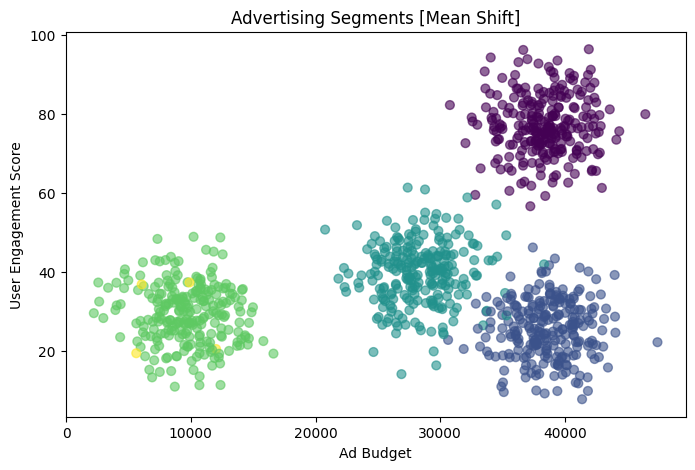

In [33]:
plt.figure(figsize = (8,5))

plt.scatter(df_sample['ad_budget'], df_sample['user_engagement_score'], c = df_sample['ms_clusters'], s = 40, alpha = 0.6)

plt.title('Advertising Segments [Mean Shift]')
plt.xlabel('Ad Budget')
plt.ylabel('User Engagement Score')

plt.show();

**Ket takeaway**

The profile report reveals an outstanding convergence with our prior density experiments:

While DBSCAN leaves outliers unassigned, Mean Shift treats them as a distinct, low-density micro-peak. This absolute consensus between two entirely different mathematical approaches (one density-bounded, one kernel-climbing) provides irrefutable structural proof that our dataset contains four highly stable customer segments and four highly significant operational anomalies.

### 7. Silhouette Score

The __Silhouette Score__ is a mathematical metric that evaluates cluster quality by grading every individual data point on a scale from -1.0 to +1.0.

For any given point, it calculates two distinct spatial properties in your 8-dimensional space:

_Cohesion_ (`a`): The average distance between that point and all other points in its own cluster. The smaller the number the tighter the cluster.

_Separation_ (`b`): The average distance between that point and all points in the nearest neighbouring cluster. The larger the number the more isolated the groups.

Score Interpretation:

- Close to +1.0: The data point is perfectly placed inside a dense cluster that is completely isolated from other groups.
- Close to 0.0: The data point sits right on the ambiguous border where two clusters overlap.
- Negative Value: The data point is closer to a neighbouring cluster than its own, meaning it has been misclassified

#### Helper function: get_silhouette_score

In [49]:
def get_sil_score(scaled_data, dataframe, cluster_column_name):

    labels = dataframe[cluster_column_name].values
    # pulls the dedicated cluster column from df

    unique_labels = set(labels)
    # pulls the unique cluster values from labels

    # Safety Check 1: to prevent model from putting everything as 1 cluster
    if len(unique_labels) < 2 or len(unique_labels) >= len(df_scaled):
        print(f'Skipping {cluster_column_name}: Silhouette requires between 2 and N-1 clusters.')
        return None

    # Safety Check 2: to prevent outliers in db_clusters to be counted as valid clusters
    if -1 in unique_labels:
        # filters out any outlier (-1) from DBSCAN clusters
        valid_mask = labels != -1
        X_eval = scaled_data[valid_mask]
        labels_eval = labels[valid_mask]

    else:

        X_eval = scaled_data
        labels_eval = labels

    score = silhouette_score(X_eval, labels_eval)

    print(f'Average Silhoette Score for {cluster_column_name}: {score:.4f}')

In [50]:
marketing_features = ['ad_budget', 'impressions', 'ctr', 'clicks', 'cpc', 'time_on_site', 'user_engagement_score', 'device_score']

df_clusters = df_sample.drop(marketing_features, axis = 1, errors = 'ignore')

for cluster_name, cluster_val in df_clusters.items():
    get_sil_score(df_scaled, df_sample, cluster_name)

Average Silhoette Score for clusters: 0.6677
Average Silhoette Score for agg_clusters: 0.4214
Average Silhoette Score for db_clusters: 0.6745
Average Silhoette Score for ms_clusters: 0.6716


**Key takeaways**

Our automated evaluation loop calculated the final average Silhouette Coefficients across all four machine learning paradigms:
1. **DBSCAN (`db_clusters`):** 0.6745 ★ (Optimal Performance)
2. **Mean Shift (`ms_clusters`):** 0.6716
3. **K-Means (`clusters`):** 0.6677
4. **Agglomerative Ward (`agg_clusters`):** 0.4214

**Interpretation**:
DBSCAN emerged as our mathematical winner with a score of 0.6745. This peak performance is driven by DBSCAN's ability to cleanly isolate the four outlying noise campaigns. By removing those highly scattered anomalies from the boundary metrics rather than forcing them into a group, DBSCAN achieved maximum compactness for our four core marketing groups.

Conversely, our Agglomerative model experienced a notable drop to 0.4214. This performance drop highlights the rigid structural limitations of hierarchical trees when handling overlapping data distributions. To satisfy its variance minimisation criteria from the bottom up, Ward's method cut certain branches in a way that misallocated borderline campaigns sitting in the data's long tails, leading to overlapping clusters and a lower silhouette rating. 

**Conclusion**:
For this specific marketing feature space, density-bounded architectures (DBSCAN) and centroid-seeking models (K-Means/Mean Shift) are highly superior to hierarchical configurations.

In [53]:
# Saving the enriched marketing sample with multiple clusters recorded.

df_sample.to_csv('enriched_marketing_sample.csv', index = False)